In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = np.array([[1],[2],[3],[4]])
y = np.array([2,4,6,8])

In [31]:
import numpy as np
import matplotlib.pyplot as plt


class RidgeRegression:
    """
    Ridge Regression implemented from scratch using Gradient Descent.

    Ridge Regression adds L2 regularization to the loss function to
    prevent overfitting and reduce model complexity.

    Loss Function:
        J = (1/n) * Σ(y - ŷ)^2 + λ * ||w||²

    Attributes:
        X (ndarray): Training features, shape (n_samples, n_features)
        y (ndarray): Target values, shape (n_samples,)
        w (ndarray): Weights, shape (n_features,)
        b (float): Bias term
        lambda_ (float): Regularization strength
        alpha (float): Learning rate
        num_iteration (int): Number of iterations
        loss_history (list): Stores loss value per iteration
    """

    def __init__(self, x, y, lambda_):
        self.x = np.array(x)
        self.y = np.array(y)
        self.lambda_ = lambda_

    def fit(self, alpha, num_iteration):
        """
        Trains the ridge regression model using gradient descent.

        Parameters:
            alpha (float): Learning rate for weight updates.
            num_iteration (int): Number of iterations for gradient descent.

        Updates:
            self.w: Trained weight(s).
            self.b: Trained bias.
            self.sse_value: Records SSE at each iteration for visualization.

        """
        n_samples, n_features = self.x.shape

        self.w = np.zeros(n_features)
        self.b = 0
        self.alpha = alpha
        self.num_iteration = num_iteration
        self.loss_history = []

        for _ in range(self.num_iteration):
            y_hat = np.dot(self.x, self.w) + self.b

            dw = (2/n_samples) * np.dot(self.x.T, (y_hat - self.y)) + 2 * self.lambda_ * self.w
            db = (2/n_samples) * np.sum(y_hat - self.y)

            self.w -= self.alpha * dw
            self.b -= self.alpha * db

            loss = (1/n_samples) * np.sum((self.y - y_hat)**2) + self.lambda_ * np.sum(self.w**2)

            self.loss_history.append(loss)


    def predict(self, x_new):
        """
            Makes predictions using the trained model.

            Parameters:
            new_x (array-like): New input data for prediction.

            Returns:
            ndarray: Predicted values for the input data.
        """
        x_new = np.array(x_new)
        return np.dot(x_new, self.w) + self.b


    def calc_MSE(self):
        """
            Calculates Mean Squared Error (MSE) of the model on training data.

            Returns:
            float: Mean Squared Error.
        """
        y_hat = self.w * self.x + self.b
        return np.mean((self.y - y_hat)**2)


    def calc_RMSE(self):
        """
            Calculates Root Mean Squared Error (RMSE) of the model on training data.

            Returns:
            float: Root Mean Squared Error.
        """      
        return np.sqrt(self.calc_MSE())


    def calc_R2Score(self):
        """
            Calculates the R-squared (coefficient of determination) of the model.

            Returns:
            float: R² score, indicates how well the model explains variance in y.
        """
        y_hat = self.predict(self.x)
        sse = np.sum((self.y - y_hat)**2)
        sst = np.sum((self.y - np.mean(self.y))**2)
        return 1 - (sse / sst)


    def visualize(self):    
            """
            Visualizes training results.

            Plots:
            1. SSE (Sum of Squared Errors) over iterations.
            2. Regression line along with original data points.
            """
            plt.figure(figsize=(12,4))
            plt.subplot(1,2,1)
            plt.plot(range(self.num_iteration) , self.loss_history, label='loss')
            plt.xlabel("Iteration")
            plt.ylabel("Loss")
            plt.title("Loss over Iteration")
            plt.legend()
            plt.subplot(1,2,2)
            plt.scatter(self.x,self.y,color="blue",label="Data point")
            plt.plot(self.x,self.w*self.x+self.b,color="red" , label="Regression line")
            plt.xlabel("x")
            plt.ylabel("Y")
            plt.title("Ridge Regression fit line")
            plt.show()

In [32]:
l4=RidgeRegression(x,y,10)
l4.fit(0.009,1000)

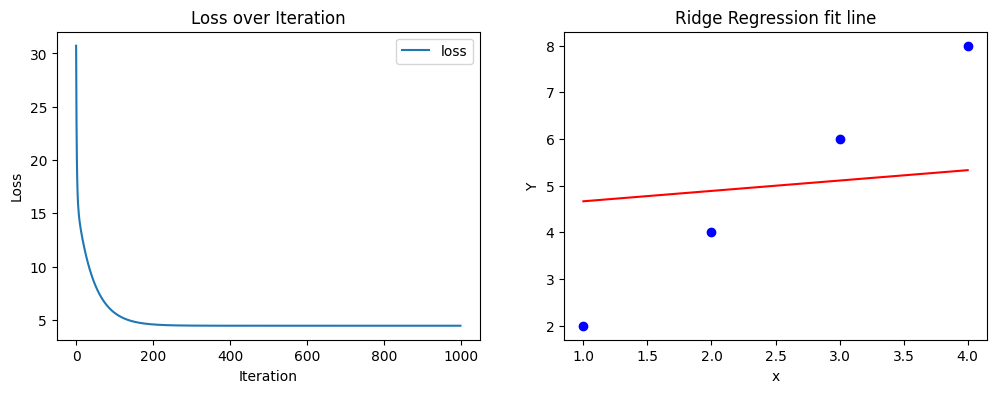

In [33]:
l4.visualize()

In [34]:
print(l4.predict(2))
print(l4.predict(3))
print(l4.calc_MSE())
print(l4.calc_RMSE())
print(l4.calc_R2Score())

[4.88885476]
[5.11108417]
5.0617323897324855
2.2498294134739383
0.20988293288812754


In [ ]:
# class RidgeRegression:
#     """
#         Ridge Regression class implements ridge regression using gradient descent.

#         Attributes:
#         X (array-like): Input features (1D or 2D).
#         y (array-like): Target values.
#         w (float or ndarray): Weight(s) for features.
#         b (float): Bias term.
#         alpha (float): Learning rate for gradient descent.
#         num_iteration (int): Number of iterations for training.
#         sse_value (list): Sum of squared errors for each iteration.
#     """
#     def __init__(self,x,y,lambda_):
#         """ 
#         Constructor to initialize input features and target.

#             Parameters:
#             x (array-like): Input feature(s), shape (n_samples,) or (n_samples, n_features).
#             y (array-like): Target values, shape (n_samples,).
            
#         """
#         self.x=np.array(x)
#         self.y=np.array(y)
#         self.lambda_=lambda_


#     def fit(self,alpha,num_iteration):
#         """
#         Trains the ridge regression model using gradient descent.

#             Parameters:
#             alpha (float): Learning rate for weight updates.
#             num_iteration (int): Number of iterations for gradient descent.

#             Updates:
#             self.w: Trained weight(s).
#             self.b: Trained bias.
#             self.sse_value: Records SSE at each iteration for visualization.

#         """
#         self.w = 0
#         self.b = 0
#         self.alpha = alpha
#         self.num_iteration= num_iteration
#         n = len(self.x)
#         self.sse_value= []
#         for i in range(self.num_iteration):
#             y_hat = self.w* self.x + self.b

#             D_w = (2/n) * np.sum((y_hat-self.y)*self.x) + (2 *self.lambda_ / n) * self.w
#             D_b = (2/n) * np.sum(y_hat-self.y) 
        

#             self.w -=  self.alpha * D_w
#             self.b -=  self.alpha * D_b
            
#             sse = (np.sum((y_hat-self.y)**2))+(self.lambda_ *  (self.w ** 2))
#             self.sse_value.append(sse)

#     def predict(self,new_x):
#             """
#             Makes predictions using the trained model.

#             Parameters:
#             new_x (array-like): New input data for prediction.

#             Returns:
#             ndarray: Predicted values for the input data.
#             """
#             new_x=np.array(new_x)
#             return self.w * new_x+ self.b
    
#     def visualize(self):    
#             """
#             Visualizes training results.

#             Plots:
#             1. SSE (Sum of Squared Errors) over iterations.
#             2. Regression line along with original data points.
#             """
#             plt.figure(figsize=(12,4))
#             plt.subplot(1,2,1)
#             plt.plot(range(self.num_iteration) , self.sse_value, label='sse')
#             plt.xlabel("Iteration")
#             plt.ylabel("SSE")
#             plt.title("SSE over Iteration")
#             plt.legend()
#             plt.subplot(1,2,2)
#             plt.scatter(self.x,self.y,color="blue",label="Data point")
#             plt.plot(self.x,self.w*self.x+self.b,color="red" , label="Regression line")
#             plt.xlabel("X")
#             plt.ylabel("Y")
#             plt.title("Ridge Regression fit line")
#             plt.show()



#     def calc_MSE(self):
#         """
#             Calculates Mean Squared Error (MSE) of the model on training data.

#             Returns:
#             float: Mean Squared Error.
#         """
#         y_hat = self.w * self.x + self.b
#         mse = np.mean((self.y - y_hat) ** 2)
#         return mse
    
#     def calc_RMSE(self):
#         """
#             Calculates Root Mean Squared Error (RMSE) of the model on training data.

#             Returns:
#             float: Root Mean Squared Error.
#         """
#         return np.sqrt(self.calc_MSE())
    
#     def calc_R2Score(self):
#             """
#             Calculates the R-squared (coefficient of determination) of the model.

#             Returns:
#             float: R² score, indicates how well the model explains variance in y.
#             """
#             y_hat = self.w * self.x + self.b
#             sse = np.sum((self.y - y_hat) ** 2)
#             sst = np.sum((self.y - np.mean(self.y)) ** 2)
#             r2  = 1 - (sse / sst)
#             return r2